In [59]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# setting the seed for numpy
np.random.seed(10)

# setting the figure parameters for matplotlib
plt.figure(figsize=(8, 6), dpi=300)

<Figure size 2400x1800 with 0 Axes>

<Figure size 2400x1800 with 0 Axes>

In [60]:
# read raw dataset
df = pd.read_csv('../data_raw/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [61]:
# check for null values in the dataset
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [49]:
# saving the dataset to cleaned folder without any preprocessing as there are no null values
df.to_csv("../data_clean/StudentsPerformance.csv", index=False)


# read again from cleaned dataset folder
df = pd.read_csv('../data_clean/StudentsPerformance.csv')

In [50]:
# check for duplicate samples in the dataset
df.duplicated().unique()

array([False])

C:\Users\Maxi\AppData\Local\Temp\ipykernel_19688\3151702517.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(math_plot_data, labels=["Male", "Female"])


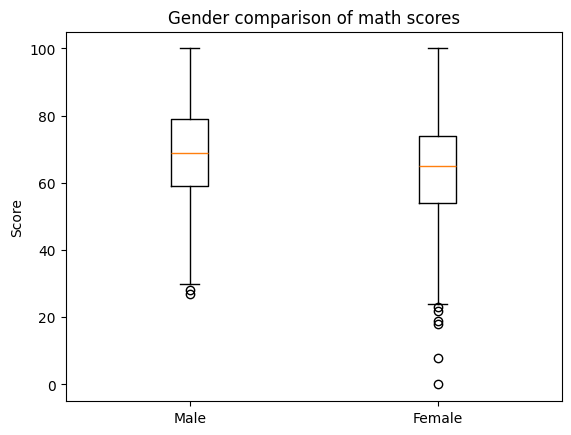

C:\Users\Maxi\AppData\Local\Temp\ipykernel_19688\3151702517.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(reading_plot_data, labels=["Male", "Female"])


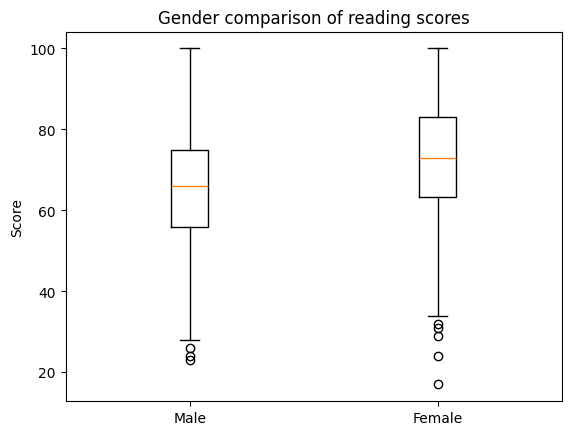

In [51]:
# splitting up the dataset for male and female
data_male = df[df['gender'] == 'male']
data_female = df[df['gender'] == 'female']

math_data_male = data_male['math score'].to_numpy()
math_data_female = data_female['math score'].to_numpy()

reading_data_male = data_male['reading score'].to_numpy()
reading_data_female = data_female['reading score'].to_numpy()

math_plot_data = [math_data_male, math_data_female]
reading_plot_data = [reading_data_male, reading_data_female]

# Create boxplot
plt.boxplot(math_plot_data, labels=["Male", "Female"])
plt.title("Gender comparison of math scores")
plt.ylabel("Score")
plt.savefig("../results/genderComparisonMathScore.png")
plt.show()

plt.boxplot(reading_plot_data, labels=["Male", "Female"])
plt.title("Gender comparison of reading scores")
plt.ylabel("Score")
plt.savefig("../results/genderComparisonReadScore.png")
plt.show()


The general observation is that the median of math scores is slightly lower than for men. the 25th quartile and the 75th quartile lines of the box plot for women also lies considerably below the respective lines for men which goes on to say that men in general have better math scores compared to women according to the dataset.

As for reading, the box plot for scores of women is higher than that of men. This means that women score better in reading than men according to the dataset

In [52]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

C:\Users\Maxi\AppData\Local\Temp\ipykernel_19688\3999205929.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(math_plot_data, labels=["Course completed", "Course not completed"])


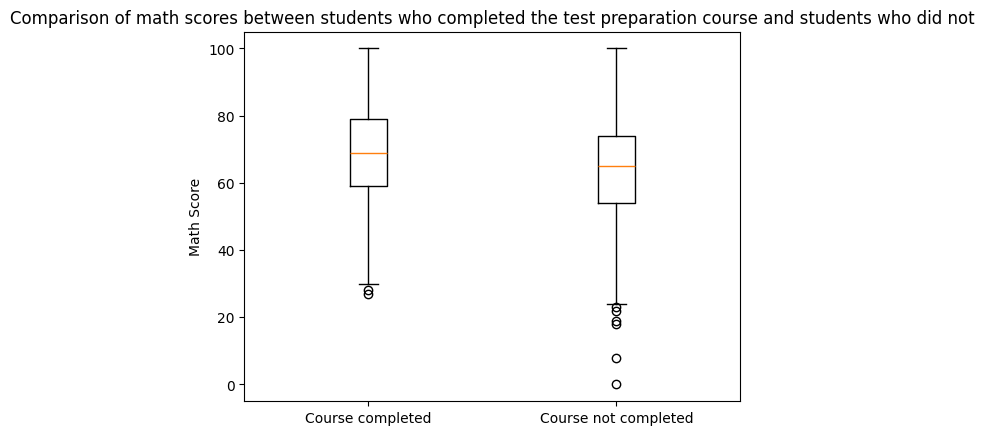

In [53]:
# splitting up the dataset for test preparation course completed and not completed and selecting the math scores
test_preparation_completed_math_scores = df[df['test preparation course'] == 'completed']['math score'].to_numpy()
test_preparation_none_math_scores = df[df['test preparation course'] == 'none']['math score'].to_numpy()

# Create boxplot
plt.boxplot(math_plot_data, labels=["Course completed", "Course not completed"])
plt.title("Comparison of math scores between students who completed the test preparation course and students who did not")
plt.ylabel("Math Score")
plt.savefig("../results/TestPrepComparisonMathScore.png")
plt.show()

The 25th quartile, median and 75th quartile lines of the box plot of math scores for students who completed the course is all slightly higher than the respective lines on plot of math scores for students who have not completed the course. This means that students who complete the course tend to perform slightly better than the ones who do not.

In [54]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

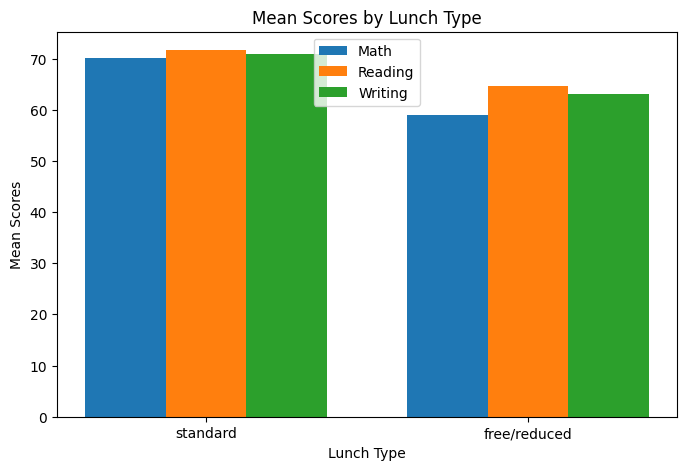

In [55]:
lunch_categories = df["lunch"].unique()

# filtering the dataset based on the type of lunch
standard_lunch = df[df["lunch"] == "standard"]
free_or_reduced_lunch = df[df["lunch"] == "free/reduced"]

math_means = [standard_lunch['math score'].mean(), free_or_reduced_lunch['math score'].mean()]
reading_means = [standard_lunch['reading score'].mean(), free_or_reduced_lunch['reading score'].mean()]
writing_means = [standard_lunch['writing score'].mean(), free_or_reduced_lunch['writing score'].mean()]

x = np.arange(len(lunch_categories))
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(8, 5))

# Bars for each subject
ax.bar(x - width, math_means, width, label="Math")
ax.bar(x, reading_means, width, label="Reading")
ax.bar(x + width, writing_means, width, label="Writing")

ax.set_xlabel("Lunch Type")
ax.set_ylabel("Mean Scores")
ax.set_title("Mean Scores by Lunch Type")
ax.set_xticks(x)
ax.set_xticklabels(lunch_categories)
ax.legend()

plt.savefig("../results/TestPrepComparisonMathScore.png")

plt.show()


This bar chart shows that students who were served standard lunch scored better in all three subjects (math, reading and writing)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


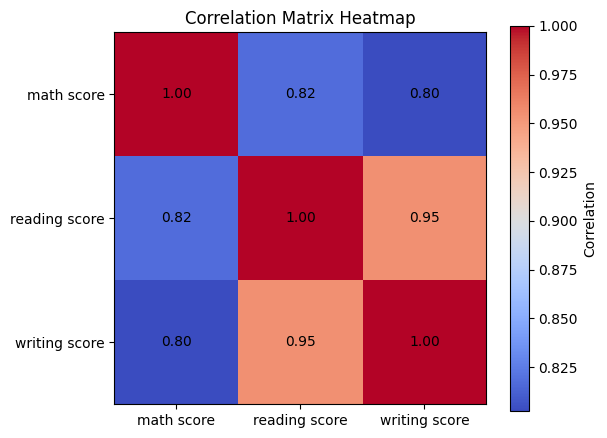

In [ ]:
# Correlation matrix
corr_matrix = df[["math score", "reading score", "writing score"]].corr()

print(corr_matrix)

plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

# Tick labels
plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)

# Annotate values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix Heatmap")
plt.savefig("../results/scoreCorrelation.png")
plt.show()



The heatmap shows that all the scores of students in all three subjects are very much correlated. This means that people who score good in math also score good in reading and writing. Especially, writing and reading scores are the most correlated ones among the three with a correlation of 95%.

In [57]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


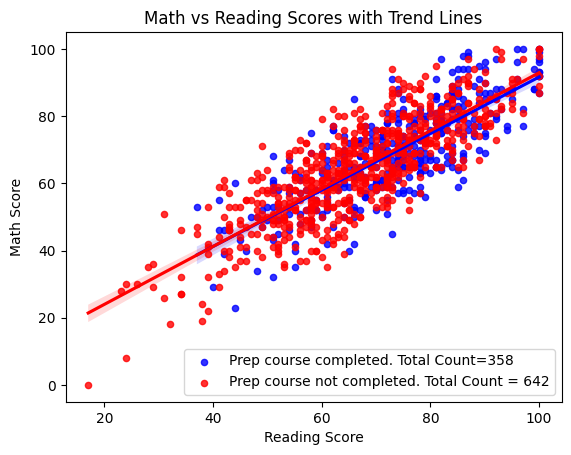

In [ ]:
df_completed = df[df['test preparation course'] == 'completed']
df_none = df[df['test preparation course'] == 'none']

math_completed = df[df['test preparation course'] == 'completed']['math score'].to_numpy()
reading_completed = df[df['test preparation course'] == 'completed']['reading score'].to_numpy()

math_none = df[df['test preparation course'] == 'none']['math score'].to_numpy()
reading_none = df[df['test preparation course'] == 'none']['reading score'].to_numpy()

# scatter plot for prep course completed
sns.regplot(x=reading_completed, y=math_completed, label=f"Prep course completed. Total Count={len(df_completed)}",
            scatter_kws={"s": 20, "color":"blue"}, line_kws={"color":"blue"})

# scatter plot for prep course none
sns.regplot(x=reading_none, y=math_none, label=f"Prep course not completed. Total Count = {len(df_none)}",
            scatter_kws={"s": 20, "color":"red"}, line_kws={"color":"red"})
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Math vs Reading Scores with Trend Lines")
plt.legend()
plt.savefig("../results/testPrepTrendLinesonMathvsReading.png")
plt.show()


The slope of the trend lines for students who completed the prep course and those who did not do not differ much. They almost have the same slope though people who did not complete the test scores have a higher slope towards the end. People who did not take the prep course and also scored higher, scored a bit better in math than reading.